In [1]:
#Importing all necessary modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as col
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sbr

In [2]:
# Reading data, checking datatypes, and filling in null values (if existing)

In [3]:
df = pd.read_csv("Housing_modified_Dataset.csv")

In [4]:
df.head()

,guestroom,hotwaterheating,parking,area,furnishingstatus,mainroad,airconditioning,bathrooms,price,basement,stories,prefarea,bedrooms
0,no,no,1,5900,unfurnished,no,no,2,4045214,yes,2,no,4
1,no,no,0,6500,furnished,yes,yes,2,6536696,no,3,yes,3
2,no,no,0,4040,semi-furnished,yes,no,1,3693404,no,1,no,2
3,no,no,0,5000,semi-furnished,yes,yes,1,6342007,no,2,no,3
4,no,no,0,3960,furnished,yes,no,1,2765070,no,1,no,3


In [5]:
df.dtypes

guestroom           object
hotwaterheating     object
parking              int64
area                 int64
furnishingstatus    object
mainroad            object
airconditioning     object
bathrooms            int64
price                int64
basement            object
stories              int64
prefarea            object
bedrooms             int64
dtype: object

In [6]:
df.fillna(0)

,guestroom,hotwaterheating,parking,area,furnishingstatus,mainroad,airconditioning,bathrooms,price,basement,stories,prefarea,bedrooms
0,no,no,1,5900,unfurnished,no,no,2,4045214,yes,2,no,4
1,no,no,0,6500,furnished,yes,yes,2,6536696,no,3,yes,3
2,no,no,0,4040,semi-furnished,yes,no,1,3693404,no,1,no,2
3,no,no,0,5000,semi-furnished,yes,yes,1,6342007,no,2,no,3
4,no,no,0,3960,furnished,yes,no,1,2765070,no,1,no,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,no,no,0,6000,unfurnished,yes,yes,2,6673593,no,4,no,4
541,no,no,0,5450,semi-furnished,yes,yes,2,6137918,yes,1,yes,4
542,no,yes,1,4500,furnished,yes,no,2,4393705,no,3,no,3
543,no,no,0,4040,unfurnished,yes,no,1,3316448,no,1,no,2


In [7]:
#Using one-hot to convert furnishing status to 3 seperate columns

In [8]:
a = list(df['furnishingstatus'])
fur=[]
semifur=[]
unfur=[]
for i in a:
    if i == 'furnished':
        fur.append(1)
        semifur.append(0)
        unfur.append(0)
    elif i == 'semi-furnished':
        fur.append(0)
        semifur.append(1)
        unfur.append(0)
    else:
        fur.append(0)
        semifur.append(0)
        unfur.append(1)

df['furnished'] = fur
df['semifurnished'] = semifur
df['unfurnished'] = unfur

df.head()

,guestroom,hotwaterheating,parking,area,furnishingstatus,mainroad,airconditioning,bathrooms,price,basement,stories,prefarea,bedrooms,furnished,semifurnished,unfurnished
0,no,no,1,5900,unfurnished,no,no,2,4045214,yes,2,no,4,0,0,1
1,no,no,0,6500,furnished,yes,yes,2,6536696,no,3,yes,3,1,0,0
2,no,no,0,4040,semi-furnished,yes,no,1,3693404,no,1,no,2,0,1,0
3,no,no,0,5000,semi-furnished,yes,yes,1,6342007,no,2,no,3,0,1,0
4,no,no,0,3960,furnished,yes,no,1,2765070,no,1,no,3,1,0,0


In [9]:
#Converting all the data to be standardized to values between 0 - 1

In [10]:
a = list(df['area'])
for i in range(len(a)):
    a[i] = a[i]/10000

df['area'] = a

In [11]:
a = list(df['price'])
for i in range(len(a)):
    a[i] = a[i]/10000
df['price'] = a

In [12]:
a = list(df['stories'])
for i in range(len(a)):
    a[i] = a[i]/4
df['stories'] = a

In [13]:
a = list(df['bedrooms'])
for i in range(len(a)):
    a[i] = a[i]/4
df['bedrooms'] = aa = list(df['bedrooms'])


In [14]:
a = list(df['bathrooms'])
for i in range(len(a)):
    a[i] = a[i]/4
df['bathrooms'] = a

In [15]:
#Converting other categorical features into numerical

In [16]:
def replacer(x):
    x=list(x)
    for i in range(len(x)):
        if x[i] == 'yes':
            x[i] = 1
        else:
            x[i] = 0
    return x

In [17]:
for i in ['guestroom', 'hotwaterheating', 'mainroad', 'airconditioning', 'basement', 'prefarea']:
    df[i] = replacer(df[i])


In [18]:
#converting each array to desired shape
#from row to column ( 1 x n to n x 1)

#Combining all into a feature array, X
#Price alone in target array, Y

In [19]:
Xguestroom = np.array(df['guestroom']).reshape(-1,1)
Xhotwaterheating = np.array(df['hotwaterheating']).reshape(-1,1)
Xparking = np.array(df['parking']).reshape(-1,1)
Xarea = np.array(df['area']).reshape(-1,1)
Xunfur = np.array(df['unfurnished']).reshape(-1,1)
Xsemifur = np.array(df['semifurnished']).reshape(-1,1)
Xfur = np.array(df['furnished']).reshape(-1,1)
Xmainroad = np.array(df['mainroad']).reshape(-1,1)
Xairconditioning = np.array(df['airconditioning']).reshape(-1,1)
Xbathrooms = np.array(df['bathrooms']).reshape(-1,1)
Xbasement = np.array(df['basement']).reshape(-1,1)
Xstories = np.array(df['stories']).reshape(-1,1)
Xprefarea = np.array(df['prefarea']).reshape(-1,1)
Xbedrooms = np.array(df['bedrooms']).reshape(-1,1)
Y = np.array(df['price']).reshape(-1,1)
X = np.hstack((Xguestroom, Xhotwaterheating, Xparking, Xarea, Xmainroad, Xairconditioning, Xbathrooms, Xbasement, Xstories, Xprefarea, Xbedrooms, Xfur, Xsemifur, Xunfur))


In [20]:
#Unused column, as it has been replaced previously

In [21]:
df.drop('furnishingstatus', axis=1, inplace=True)

In [22]:
# Creating copies of variables, one set manually used, other set used with sklearn

In [23]:
dfsk = df
Xsk = X
Ysk = Y

In [24]:
#MANUAL

In [25]:
#Starting process with randomized weights and biases

In [26]:
weights = np.random.randn(14, 1) * 0.01
bias = 0

In [27]:
#Function to split into training and test data
#Splits predictably, no randomness 

In [28]:
def splitter(X, Y, frac):
    numTest = int(len(X) * frac)
    Xtest = X[0:numTest]
    Ytest = Y[0:numTest]
    X = X[numTest:-1]
    Y = Y[numTest:-1]
    return([X, Y, Xtest, Ytest])
    

In [29]:
a = splitter(X, Y, 0.1)
X, Y, Xtest, Ytest = a

In [30]:
#Functions to implement the gradient descent, and calculate mse/cost

In [31]:
def pred(X, weights, bias):
    Ypred = np.matmul(X, weights)
    for i in range(len(Ypred)):
        Ypred[i][0] = Ypred[i][0] + bias
    return Ypred


In [32]:
def cost(Y, Ypred):
    return np.mean((Y - Ypred) ** 2)

def descent(Y, Ypred, X, weights):

    db = 2 * (np.mean(Ypred - Y))
    dw = []
    for i in range(len(weights)):
        dw.append(2 * (np.mean(np.multiply((Ypred - Y), (X[: , i]).reshape(-1, 1)))))
    return ([dw, db])

def update(weights, bias, dw, db, learning_rate):
    for i in range(len(weights)):
        weights[i][0] = weights[i][0] - learning_rate * dw[i]
    bias = bias - learning_rate * db 
    return (weights, bias)

In [33]:
#LEARNING PROCESS 

In [34]:
costgraph = []
for i in range(3000):
    Ypred = pred(X, weights, bias)
    c = cost(Y, Ypred)
    a = descent(Y, Ypred, X, weights)
    dw = a[0]
    db = a[1]
    weights, bias = update(weights, bias, dw, db, 0.0001)
    costgraph.append(c)


In [35]:
#Visualising lowering of Cost 

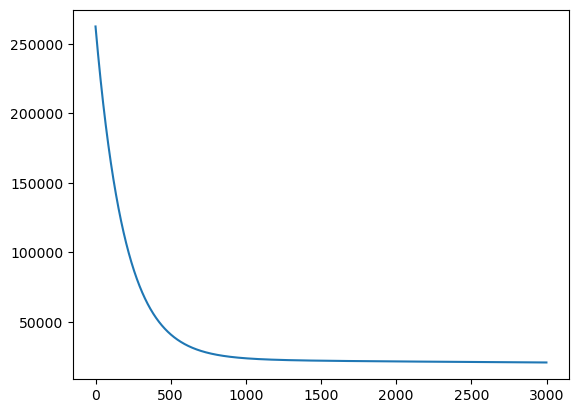

In [36]:
plt.plot(costgraph)

In [37]:
testPred = pred(Xtest, weights, bias)
testCost = cost(Ytest, testPred)


In [38]:
#Calculating Mse and r^2

In [39]:
mse = testCost
print('mean squared error is : ', mse)


mean squared error is :  28991.87872106623


In [40]:
def rSq (Ytest, testPred, mse):
    Y.reshape(-1)
    Ypred.reshape(-1)
    YmeanVal = np.mean(Y)
    Ymean = []
    for i in range(len(Y)):
        Ymean.append(YmeanVal)
    mseMean = cost(Y, Ymean)

    return( 1 - (mse / mseMean))
    

In [41]:
print("The r^2 value is : ", rSq(Y, Ypred, mse))

The r^2 value is :  0.1344846821995681


In [42]:
#This is not a great score right now, but can be improved with more time

In [43]:
#Printing weights and biases

In [44]:
a = weights
print("The weights are as follows:")
dict={'guestroom': float(a[0][0]), 'hot water': float(a[1][0]), 'parking': float(a[2][0]), 'area': float(a[3][0]), 'main road': float(a[4][0]), 'air con': float(a[5][0]), 'bathrooms': float(a[6][0]), 'basement': float(a[7][0]), 'stories': float(a[8][0]), 'prefarea': float(a[9][0]), 'bedrooms': float(a[10][0]), 'furnished': float(a[11][0]), 'semifurnished': float(a[12][0]), 'unfurnished': float(a[13][0])}
for i in dict:
    print(f"{i:<13}  :  {dict[i]}")

The weights are as follows:
guestroom      :  14.553508695628963
hot water      :  3.769634429359979
parking        :  39.86136382502012
area           :  27.440200792051527
main road      :  39.455053075987855
air con        :  25.672067128673465
bathrooms      :  16.367732044341455
basement       :  18.62391058871889
stories        :  21.580201023018134
prefarea       :  18.141389663363366
bedrooms       :  105.55536977420927
furnished      :  17.328521897614557
semifurnished  :  16.149665019417714
unfurnished    :  3.989201512790552


In [45]:
print("Bias is : ", bias)

Bias is :  37.47030068750667


In [46]:
#Scatter plot of expected vs predicted 

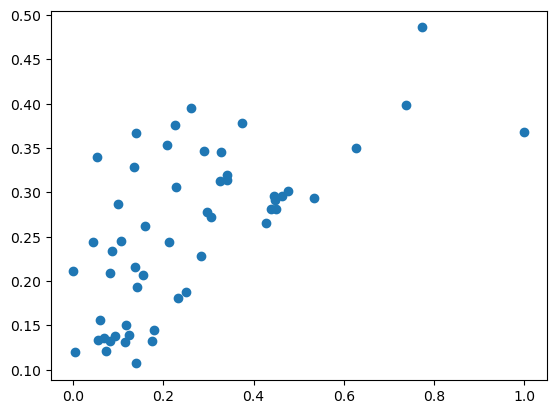

In [47]:
norm = col.Normalize()
plt.scatter(norm(Ytest), norm(testPred), marker='o')

In [48]:
# SKLEARN

In [49]:
#Splitting data

In [50]:
Xtrainsk, Xtestsk, Ytrainsk, Ytestsk = train_test_split(Xsk, Ysk, test_size = 0.1, random_state = 4000)

In [51]:
#Linear regression implementation

In [52]:
model = LinearRegression().fit(Xtrainsk, Ytrainsk)

In [53]:
Ypredictionsk = model.predict(Xtestsk)

In [54]:
#Mse and r^2 values

In [55]:
msesk = mean_squared_error(Ytestsk,Ypredictionsk)
r2sk = r2_score(Ytestsk, Ypredictionsk)
print('mean squared error is : ', msesk)
print('R^2 value is          : ', r2sk)

mean squared error is :  5738.615795482912
R^2 value is          :  0.8029961525254001


In [56]:
#R^2 value is 1 for a perfect model, and here we get 0.8
#This shows prepared model has good performance

In [57]:
#Retrieving values of bias, and weights

In [58]:
print("Bias is : ", model.intercept_[0])

Bias is :  -10.870288423830686


In [59]:
a=list(model.coef_.reshape(-1, 1))
print("The weights are as follows:")
dict={'guestroom': float(a[0][0]), 'hot water': float(a[1][0]), 'parking': float(a[2][0]), 'area': float(a[3][0]), 'main road': float(a[4][0]), 'air con': float(a[5][0]), 'bathrooms': float(a[6][0]), 'basement': float(a[7][0]), 'stories': float(a[8][0]), 'prefarea': float(a[9][0]), 'bedrooms': float(a[10][0]), 'furnished': float(a[11][0]), 'semifurnished': float(a[12][0]), 'unfurnished': float(a[13][0])}
for i in dict:
    print(f"{i:<13}  :  {dict[i]}")

The weights are as follows:
guestroom      :  32.18948037202842
hot water      :  83.15681680083266
parking        :  29.07588309899257
area           :  236.01055302839362
main road      :  45.277954760296865
air con        :  87.02491229920334
bathrooms      :  408.18732422203504
basement       :  30.094207583087616
stories        :  164.08290088751212
prefarea       :  66.4692844256964
bedrooms       :  13.229604070487877
furnished      :  17.522731591700108
semifurnished  :  9.404895568998214
unfurnished    :  -26.927627160698442


In [60]:
#Plotting Predicted price versus actual price

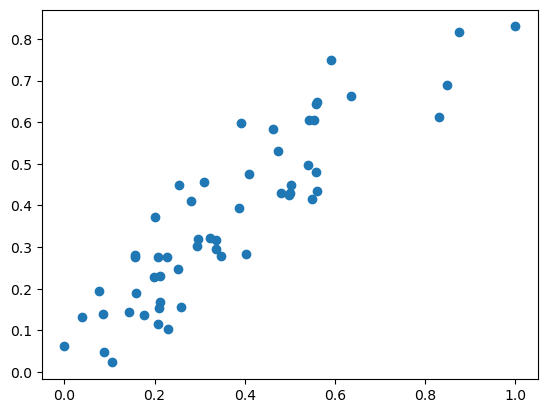

In [61]:
norm = col.Normalize()
plt.scatter(norm(Ytestsk), norm(Ypredictionsk), marker='o')

In [62]:
#Ideal graph plot would look like this

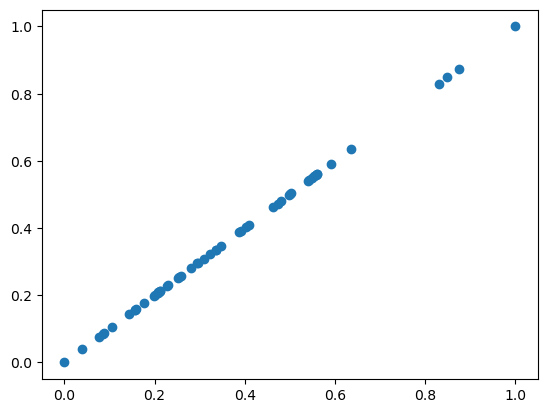

In [63]:
plt.scatter(norm(Ytestsk), norm(Ytestsk), marker='o')

In [64]:
#Plotting dependance of price with a few features

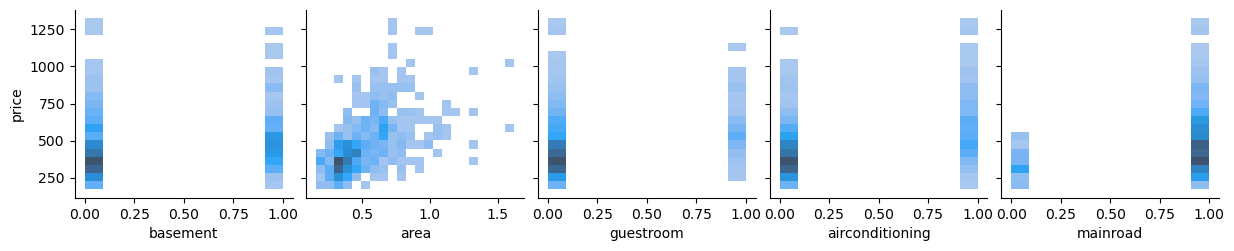

In [65]:
sbr.pairplot(dfsk, y_vars=['price'], kind = 'hist' , x_vars = ['basement', 'area', 'guestroom', 'airconditioning', 'mainroad'])

<Axes: >

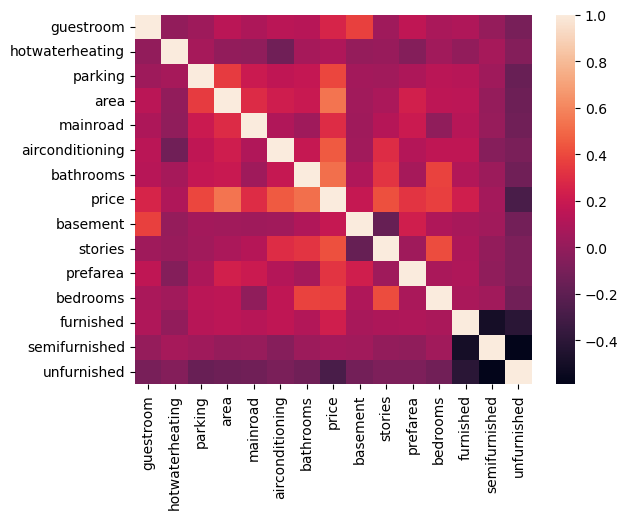

In [66]:
sbr.heatmap(dfsk.corr())